# Segmentierungspipeline – Forster-Handschriften

Pipeline: Analyse → Deskew → Sauvola → YOLO-Layoutanalyse → Kraken-Zeilensegmentierung → Line-Crops → JSON-Manifest

**Eingabe:** `data/forster1-2_auswahl_mit_text/*.jpg`  
**Ausgabe:** `data/line_crops/<page_id>/`, `data/manifests/`

In [14]:
import os
import json
import warnings
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image, ImageDraw
from tqdm import tqdm

from skimage.filters import threshold_sauvola
from skimage.color import rgb2gray
from scipy.ndimage import rotate as nd_rotate

warnings.filterwarnings('ignore')

# --- Projektwurzel (funktioniert egal ob Jupyter aus notebooks/ oder Root gestartet) ---
REPO_ROOT = Path.cwd()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR      = REPO_ROOT / 'data/forster_test_auswahl'
CROPS_DIR     = REPO_ROOT / 'data/test_set_line_crops'
MANIFEST_DIR  = REPO_ROOT / 'data/test_set_manifests'
CROPS_DIR.mkdir(parents=True, exist_ok=True)
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)

# --- Parameter (bei 300 DPI) ---
SKEW_THRESHOLD_DEG = 0.5   # Deskew nur wenn |angle| > threshold
PAD_TOP_PX         = 18    # ~1.8mm Puffer für Oberlängen
PAD_BOTTOM_PX      = 12    # ~1.2mm Puffer für Unterlängen
SAUVOLA_WIN_SIZE   = 51    # Fenster für adaptive Schwellwertberechnung
SAUVOLA_K          = 0.15

# --- YOLO-Klassen die als Textregionen gelten ---
# DocLayout-YOLO DocStructBench-Klassen die als Textregionen gelten
# Alle Klassen: title, plain text, abandon, figure, figure_caption,
#               table, table_caption, table_footnote, isolate_formula, formula_caption
YOLO_TEXT_CLASSES  = {'plain text', 'title'}
YOLO_CONF          = 0.35

JPEG_FILES = sorted(DATA_DIR.glob('*.jpg'))
print(f'Gefundene Seiten: {len(JPEG_FILES)}')
for f in JPEG_FILES:
    print(f'  {f.name}')

Gefundene Seiten: 6
  B1_P_206.jpg
  B2_P_260.jpg
  B3_P_162.jpg
  B4_P_178.jpg
  B5_P_279.jpg
  B6_P_060.jpg


---
## 1. Analyse eines Sample-JPEG

Bevor irgendwas vorverarbeitet wird: Bild-Eigenschaften verstehen.

Datei      : B1_P_206.jpg
Auflösung  : 1711 x 2462 px
Modus      : RGB
DPI        : (300.0, 300.0)
Dateigröße : 750 KB

Helligkeit (Mean/Std): 186.6 / 47.3
Dunkel (<100): 10.4%  (≈Tintenanteil)
Hell  (>200): 60.2%  (≈Hintergrund)


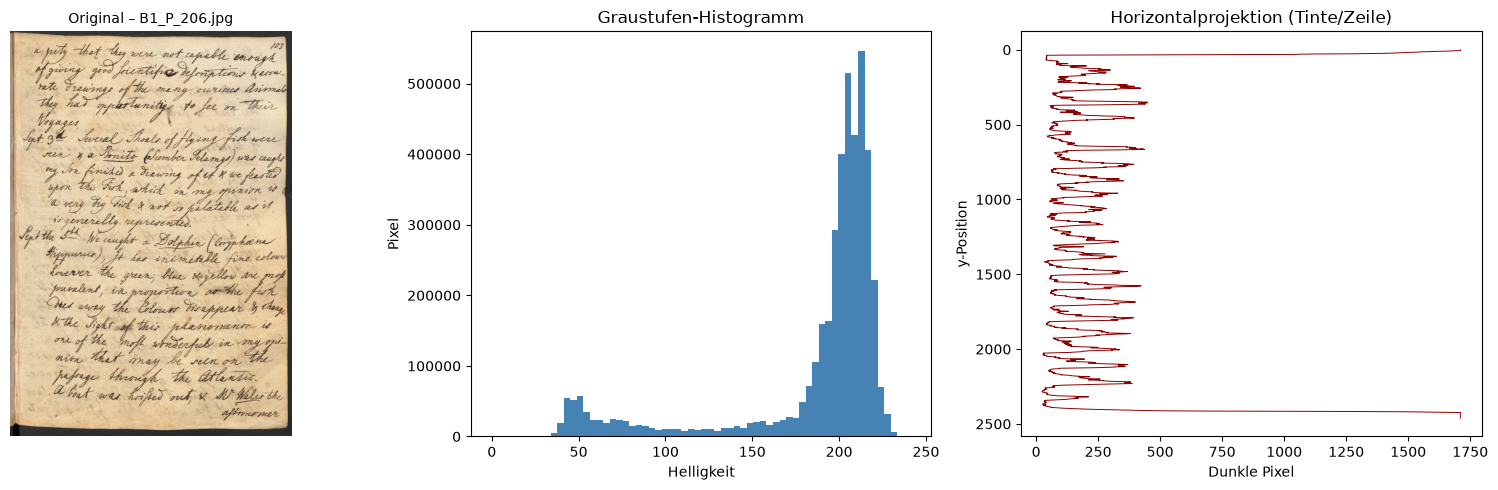

In [15]:
SAMPLE = JPEG_FILES[0]
sample_pil = Image.open(SAMPLE)
sample_np  = np.array(sample_pil)
sample_gray = np.array(sample_pil.convert('L'))

print(f'Datei      : {SAMPLE.name}')
print(f'Auflösung  : {sample_pil.size[0]} x {sample_pil.size[1]} px')
print(f'Modus      : {sample_pil.mode}')
print(f'DPI        : {sample_pil.info.get("dpi", "nicht gesetzt")}')
print(f'Dateigröße : {SAMPLE.stat().st_size // 1024} KB')
print()
print(f'Helligkeit (Mean/Std): {sample_gray.mean():.1f} / {sample_gray.std():.1f}')
print(f'Dunkel (<100): {100*(sample_gray<100).mean():.1f}%  (≈Tintenanteil)')
print(f'Hell  (>200): {100*(sample_gray>200).mean():.1f}%  (≈Hintergrund)')

# Visueller Überblick: Bild + Helligkeitshistogramm + Horizontalprojektionsprofil
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(sample_pil)
axes[0].set_title(f'Original – {SAMPLE.name}', fontsize=10)
axes[0].axis('off')

axes[1].hist(sample_gray.ravel(), bins=64, color='steelblue', edgecolor='none')
axes[1].set_title('Graustufen-Histogramm')
axes[1].set_xlabel('Helligkeit'); axes[1].set_ylabel('Pixel')

# Horizontales Projektionsprofil: dunkle Pixel pro Zeile → sichtbar als Textzeilenmuster
proj = (sample_gray < 128).sum(axis=1)
axes[2].plot(proj, np.arange(len(proj)), color='darkred', lw=0.7)
axes[2].invert_yaxis()
axes[2].set_title('Horizontalprojektion (Tinte/Zeile)')
axes[2].set_xlabel('Dunkle Pixel'); axes[2].set_ylabel('y-Position')

plt.tight_layout()
plt.show()

In [16]:
# Beleuchtungsgleichmäßigkeit: Mittelwert in 4 Quadranten
h, w = sample_gray.shape
quads = {
    'oben-links' : sample_gray[:h//2, :w//2],
    'oben-rechts': sample_gray[:h//2, w//2:],
    'unten-links': sample_gray[h//2:, :w//2],
    'unten-rechts':sample_gray[h//2:, w//2:],
}
means = {k: v.mean() for k, v in quads.items()}
print('Quadranten-Helligkeit:')
for k, m in means.items():
    print(f'  {k:<14}: {m:.1f}')
print(f'  Range: {max(means.values())-min(means.values()):.1f} (>15 → Sauvola empfehlenswert)')

Quadranten-Helligkeit:
  oben-links    : 191.3
  oben-rechts   : 189.6
  unten-links   : 186.4
  unten-rechts  : 179.0
  Range: 12.3 (>15 → Sauvola empfehlenswert)


---
## 2. Deskew & Sauvola – Notwendigkeit

### Deskew
Die Seiten zeigen Schrägstellungen zwischen **0° und ~2.2°**. Auch kleine Winkel degradieren  
die Baseline-Segmentierung, weil Kraken horizontale Zeilenverläufe erwartet.  
**Entscheidung: Deskew aktiv, Schwelle 0.5°**

### Sauvola
Der Helligkeits-Range über Quadranten liegt bei ~7–11 Punkten – moderat.  
Kraken führt intern eigene Binarisierung durch, Sauvola ist daher **kein Pflichtschritt**.  
Er wird dennoch implementiert und visualisiert, weil er als optionale Vorverarbeitung  
bei starkem Hintergrundrauschen hilfreich sein kann.


In [17]:
def estimate_skew(gray: np.ndarray) -> float:
    """Schätzt Schrägstellungswinkel via HoughLinesP auf fast-horizontalen Linien."""
    edges = cv2.Canny(gray, 50, 150, apertureSize=3)
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100,
                             minLineLength=100, maxLineGap=10)
    if lines is None:
        return 0.0
    angles = []
    for line in lines:
        x1, y1, x2, y2 = line[0]
        if x2 != x1:
            angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))
            if abs(angle) < 10:   # nur fast-horizontale Linien (Textzeilen)
                angles.append(angle)
    return float(np.median(angles)) if angles else 0.0


# Schrägenanalyse aller Seiten
skew_results = {}
print('{:<20} {:>8}  {}'.format('Datei', 'Winkel', 'Deskew?'))
print('-' * 42)
for jpg in JPEG_FILES:
    gray = np.array(Image.open(jpg).convert('L'))
    angle = estimate_skew(gray)
    needs = abs(angle) > SKEW_THRESHOLD_DEG
    skew_results[jpg.stem] = angle
    print(f'{jpg.name:<20} {angle:>+7.2f}°  {"✓" if needs else "–"}')

Datei                  Winkel  Deskew?
------------------------------------------
B1_P_206.jpg           +0.82°  ✓
B2_P_260.jpg           +0.90°  ✓
B3_P_162.jpg           +0.00°  –
B4_P_178.jpg           +0.91°  ✓
B5_P_279.jpg           +0.00°  –
B6_P_060.jpg           +0.95°  ✓


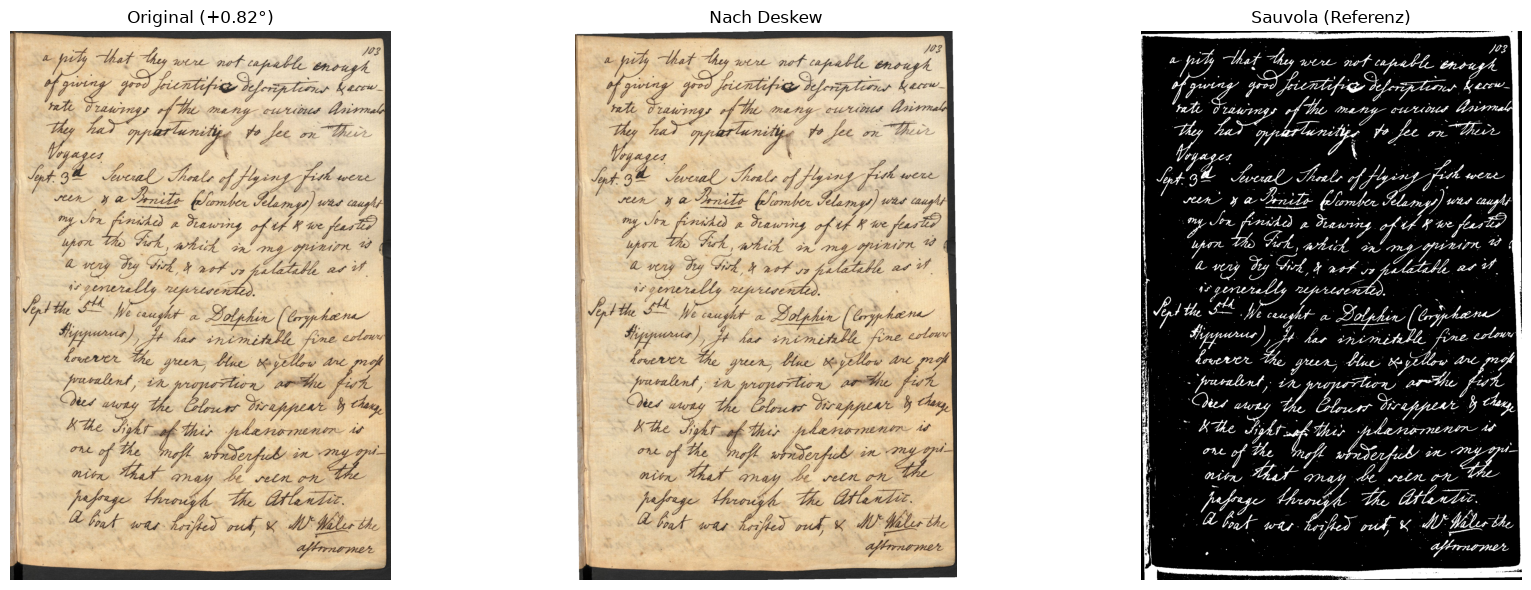

In [18]:
def deskew_image(pil_img: Image.Image, angle: float) -> Image.Image:
    """Dreht ein PIL-Bild um angle Grad; füllt freie Ecken mit Weiß."""
    if abs(angle) <= SKEW_THRESHOLD_DEG:
        return pil_img
    arr = np.array(pil_img)
    rotated = nd_rotate(arr, angle, reshape=False, cval=255, mode='constant')
    return Image.fromarray(rotated.astype(np.uint8))


def sauvola_binarize(pil_img: Image.Image) -> Image.Image:
    """Gibt ein binäres PIL-Bild zurück (schwarz=Tinte, weiß=Hintergrund)."""
    gray = rgb2gray(np.array(pil_img.convert('RGB')))
    thresh = threshold_sauvola(gray, window_size=SAUVOLA_WIN_SIZE, k=SAUVOLA_K)
    binary = (gray < thresh).astype(np.uint8) * 255
    return Image.fromarray(binary, mode='L')


# Visualisierung: Original → deskewed → Sauvola auf Sample
angle_sample = skew_results[SAMPLE.stem]
deskewed_sample = deskew_image(sample_pil, angle_sample)
sauvola_sample  = sauvola_binarize(deskewed_sample)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(sample_pil);    axes[0].set_title(f'Original ({angle_sample:+.2f}°)'); axes[0].axis('off')
axes[1].imshow(deskewed_sample); axes[1].set_title('Nach Deskew'); axes[1].axis('off')
axes[2].imshow(sauvola_sample, cmap='gray'); axes[2].set_title('Sauvola (Referenz)'); axes[2].axis('off')
plt.tight_layout(); plt.show()

---
## 3. YOLO – Layoutanalyse

YOLO erkennt Seitenregionen (Textblock, Kolumne, Seitenzahl, Marginalien).  
Kraken segmentiert dann **nur innerhalb erkannter Textregionen** – das verhindert, dass  
Randmarkierungen und Seitenzahlen als Textzeilen gespeichert werden.

**Modell-Empfehlung:** [`juliozhao/DocLayout-YOLO-DocStructBench`](https://huggingface.co/juliozhao/DocLayout-YOLO-DocStructBench)  
Alternativ ein eigens auf historische Manuskriptseiten fine-getuntes YOLOv8-Modell.  
Fehlt ein Modell, greift der Fallback auf Vollbild-Segmentierung mit Kontur-basierter ROI.

In [19]:
from huggingface_hub import hf_hub_download
from doclayout_yolo import YOLOv10

YOLO_MODEL_REPO = 'juliozhao/DocLayout-YOLO-DocStructBench'
YOLO_MODEL_FILE = 'doclayout_yolo_docstructbench_imgsz1024.pt'

try:
    model_path = hf_hub_download(repo_id=YOLO_MODEL_REPO, filename=YOLO_MODEL_FILE)
    yolo_model = YOLOv10(model_path)
    YOLO_AVAILABLE = True
    print(f'DocLayout-YOLO geladen: {YOLO_MODEL_FILE}')
    print(f'Klassen: {list(yolo_model.names.values())}')
except Exception as e:
    YOLO_AVAILABLE = False
    print(f'YOLO nicht verfügbar: {e}')
    print('Fallback: gesamte Seitenfläche als Textregion.')

DocLayout-YOLO geladen: doclayout_yolo_docstructbench_imgsz1024.pt
Klassen: ['title', 'plain text', 'abandon', 'figure', 'figure_caption', 'table', 'table_caption', 'table_footnote', 'isolate_formula', 'formula_caption']


1 Textregion(en) erkannt:
  text         conf=1.00  bbox=[0, 0, 1711, 2462]


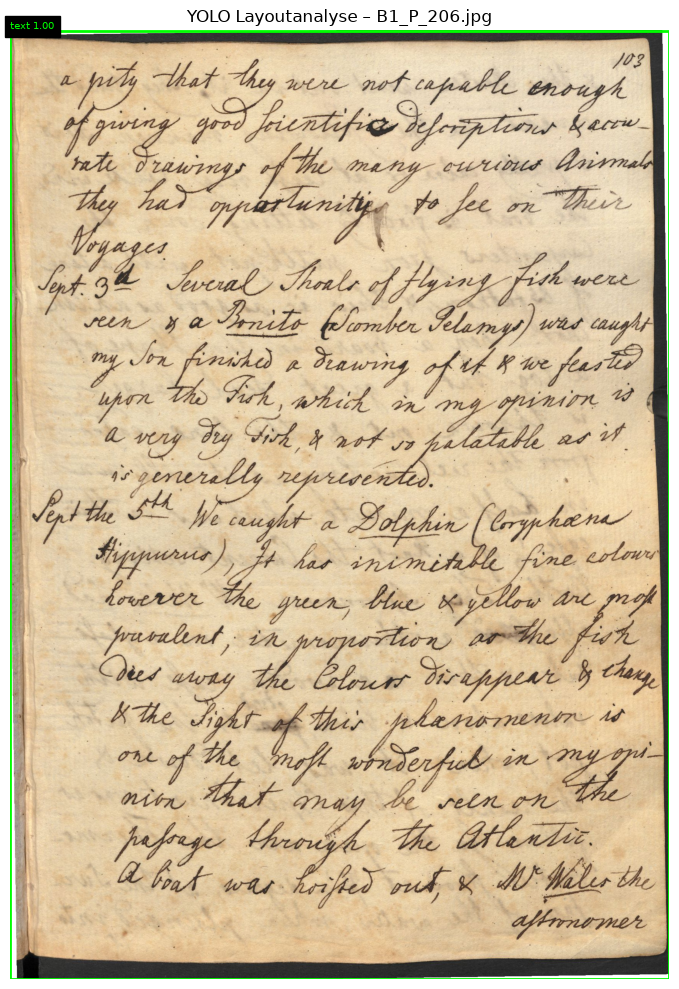

In [20]:
def detect_text_regions(pil_img: Image.Image, page_id: str) -> list[dict]:
    """
    Erkennt Textregionen via YOLO.
    Gibt Liste von {'bbox': [x1,y1,x2,y2], 'label': str, 'conf': float} zurück.
    Fallback: eine Region über die gesamte Seite.
    """
    W, H = pil_img.size

    if not YOLO_AVAILABLE:
        return [{'bbox': [0, 0, W, H], 'label': 'text', 'conf': 1.0}]

    results = yolo_model.predict(pil_img, imgsz=1024, conf=YOLO_CONF, verbose=False)
    regions = []
    for box in results[0].boxes:
        cls_name = yolo_model.names[int(box.cls)]
        conf = float(box.conf)
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0]]
        regions.append({'bbox': [x1, y1, x2, y2], 'label': cls_name, 'conf': conf})

    # Filter: nur Textklassen behalten; kein Treffer → Vollbild
    text_regions = [r for r in regions if r['label'] in YOLO_TEXT_CLASSES]
    if not text_regions:
        return [{'bbox': [0, 0, W, H], 'label': 'text', 'conf': 1.0}]
    return text_regions


def visualize_regions(pil_img: Image.Image, regions: list[dict], title: str = ''):
    fig, ax = plt.subplots(figsize=(7, 10))
    ax.imshow(pil_img)
    colors = {'text': 'lime', 'paragraph': 'cyan', 'heading': 'orange',
              'caption': 'magenta', 'list-item': 'yellow'}
    for r in regions:
        x1, y1, x2, y2 = r['bbox']
        c = colors.get(r['label'], 'red')
        rect = mpatches.Rectangle((x1, y1), x2-x1, y2-y1,
                                   linewidth=2, edgecolor=c, facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-4, f"{r['label']} {r['conf']:.2f}",
                color=c, fontsize=7, backgroundcolor='black')
    ax.set_title(title); ax.axis('off')
    plt.tight_layout(); plt.show()


# Test auf Sample-Seite
sample_regions = detect_text_regions(deskewed_sample, SAMPLE.stem)
print(f'{len(sample_regions)} Textregion(en) erkannt:')
for r in sample_regions:
    print(f"  {r['label']:<12} conf={r['conf']:.2f}  bbox={r['bbox']}")
visualize_regions(deskewed_sample, sample_regions, title=f'YOLO Layoutanalyse – {SAMPLE.name}')

---
## 4. Kraken – Zeilensegmentierung (baseline-basiert)

Kraken's `blla.segment()` erkennt Baselines und dazugehörige Boundary-Polygone.  
Das Boundary-Polygon schließt bereits einen Großteil der Oberlängen/Unterlängen ein,  
wird aber noch um `PAD_TOP_PX` / `PAD_BOTTOM_PX` erweitert.

In [21]:
from kraken import blla
from kraken.lib import models as kraken_models

# Standard-Modell laden (wird beim ersten Aufruf heruntergeladen ~7MB)
# Für historische Dokumente: eigenes finetuned Modell via kraken_models.load_any('path.mlmodel')
KRAKEN_MODEL = None  # None → blla verwendet Standardmodell

print('Kraken geladen. Modell: Standard (None = blla Default)')

Kraken geladen. Modell: Standard (None = blla Default)


Segmentiere Sample-Seite ...
Erkannte Zeilen: 24
Baseline-Punkte Zeile 1: [(1553, 91), (1646, 88)] ...
Boundary-Punkte Zeile 1: 13


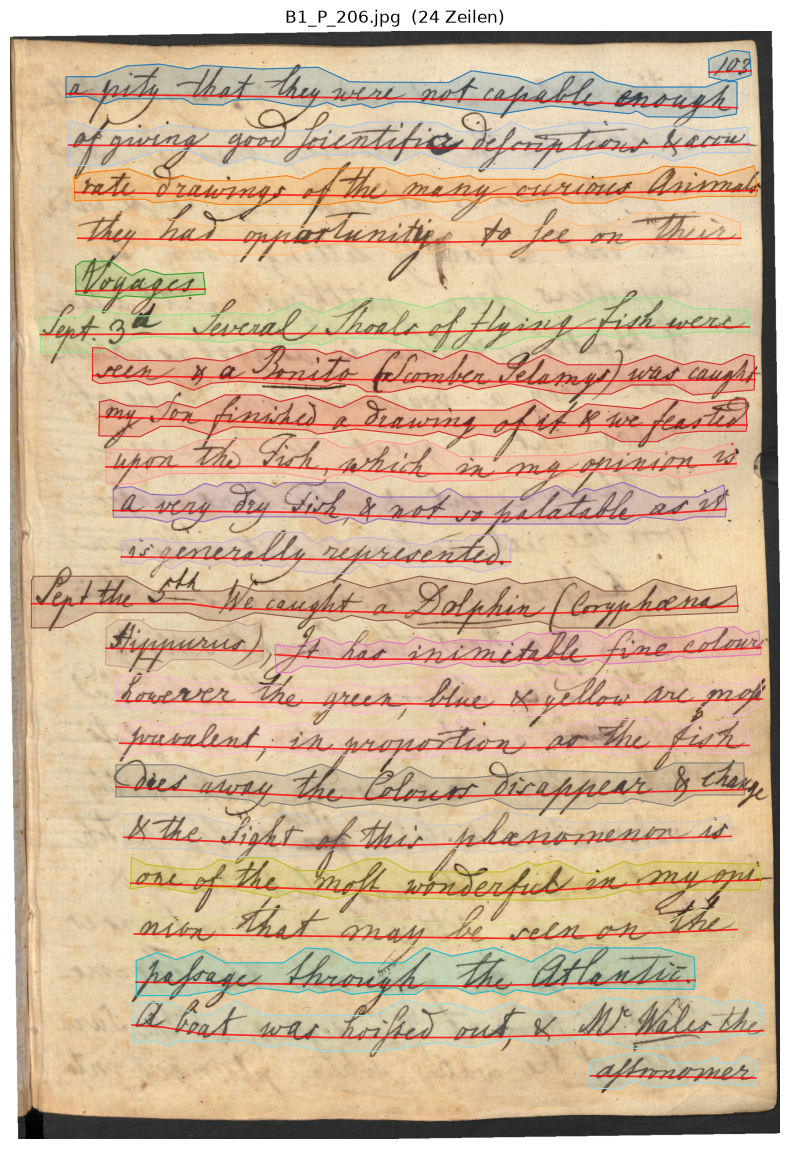

In [22]:
def segment_page(pil_img: Image.Image, regions: list[dict]) -> list:
    """
    Führt Kraken blla-Segmentierung durch.
    Wenn mehrere Regionen erkannt → segmentiert pro Region, gibt alle Lines zurück.
    Returns list of BaselineLine objects.
    """
    all_lines = []
    W, H = pil_img.size

    for region in regions:
        x1, y1, x2, y2 = region['bbox']
        # Region-Crop für Segmentierung
        crop = pil_img.crop((x1, y1, x2, y2))

        seg = blla.segment(crop, model=KRAKEN_MODEL)

        # Baselines/Boundaries zurück auf Vollbild-Koordinaten transformieren
        for line in seg.lines:
            shifted_baseline = [(px + x1, py + y1) for px, py in line.baseline]
            shifted_boundary = [(px + x1, py + y1) for px, py in line.boundary]
            line.baseline = shifted_baseline
            line.boundary = shifted_boundary
            line._region_label = region['label']
            all_lines.append(line)

    return all_lines


def visualize_segmentation(pil_img: Image.Image, lines: list, title: str = '', max_lines: int = 60):
    fig, ax = plt.subplots(figsize=(8, 12))
    ax.imshow(pil_img)
    cmap = plt.colormaps['tab20'].resampled(min(len(lines), max_lines))
    for i, line in enumerate(lines[:max_lines]):
        color = cmap(i % max_lines)
        # Boundary-Polygon
        if line.boundary:
            bnd = np.array(line.boundary)
            ax.fill(bnd[:,0], bnd[:,1], alpha=0.18, color=color)
            ax.plot(np.append(bnd[:,0], bnd[0,0]),
                    np.append(bnd[:,1], bnd[0,1]),
                    '-', lw=0.7, color=color)
        # Baseline
        if line.baseline:
            bl = np.array(line.baseline)
            ax.plot(bl[:,0], bl[:,1], 'r-', lw=1.2, alpha=0.8)
    ax.set_title(f'{title}  ({len(lines)} Zeilen)'); ax.axis('off')
    plt.tight_layout(); plt.show()


# Test-Segmentierung auf Sample-Seite
print('Segmentiere Sample-Seite ...')
sample_lines = segment_page(deskewed_sample, sample_regions)
print(f'Erkannte Zeilen: {len(sample_lines)}')
if sample_lines:
    print(f'Baseline-Punkte Zeile 1: {sample_lines[0].baseline[:3]} ...')
    print(f'Boundary-Punkte Zeile 1: {len(sample_lines[0].boundary)}')

visualize_segmentation(deskewed_sample, sample_lines, title=SAMPLE.name)

---
## 5. Zeilenbilder zuschneiden und speichern

Aus dem Boundary-Polygon wird ein achsenparalleles Bounding-Box-Crop erzeugt.  
Padding `PAD_TOP_PX` / `PAD_BOTTOM_PX` sichert Oberlängen (d, l, h …) und Unterlängen (g, p, y …).

Gespeicherte Zeilenbilder: 24
Ausgabeverzeichnis: /home/justin/Ginger_Gradient/14/project/Capstone-Project/data/test_set_line_crops/B1_P_206


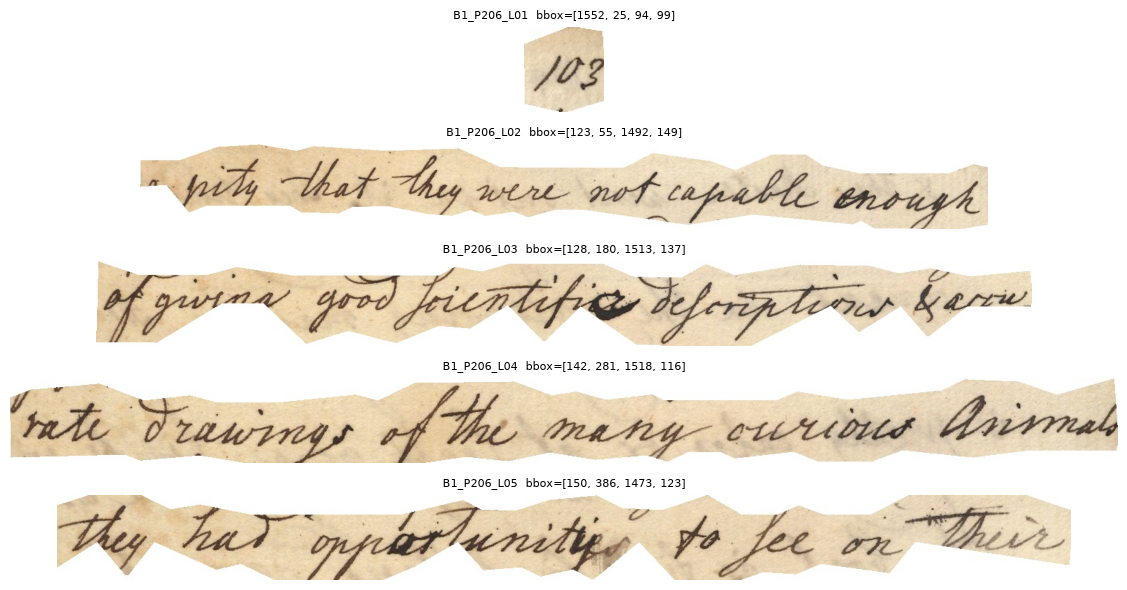

In [23]:
def extract_line_crops(
    pil_img: Image.Image,
    lines: list,
    page_id: str,
    out_dir: Path,
    pad_top: int = PAD_TOP_PX,
    pad_bottom: int = PAD_BOTTOM_PX,
) -> list[dict]:
    """
    Schneidet Zeilenbilder aus pil_img und speichert sie.
    Das Boundary-Polygon wird als Maske verwendet: Pixel außerhalb
    des Polygons werden weiß – so passt sich der Crop dem Textinhalt an.
    """
    W, H = pil_img.size
    out_dir.mkdir(parents=True, exist_ok=True)
    records = []

    for idx, line in enumerate(lines):
        if not line.boundary:
            continue

        pts = np.array(line.boundary, dtype=int)
        x1 = max(0, int(pts[:, 0].min()))
        x2 = min(W, int(pts[:, 0].max()))
        y1 = max(0, int(pts[:, 1].min()) - pad_top)
        y2 = min(H, int(pts[:, 1].max()) + pad_bottom)

        if x2 - x1 < 10 or y2 - y1 < 5:
            continue

        # Polygon-Maske: obere Punkte um pad_top anheben, untere um pad_bottom absenken
        median_y = float(np.median(pts[:, 1]))
        expanded = [
            (x, max(0, y - pad_top)  if y <= median_y else min(H, y + pad_bottom))
            for x, y in line.boundary
        ]

        mask = Image.new('L', (W, H), 0)
        ImageDraw.Draw(mask).polygon(expanded, fill=255)

        # Crop auf Bounding-Box
        img_crop  = pil_img.crop((x1, y1, x2, y2))
        mask_crop = mask.crop((x1, y1, x2, y2))

        # Weißer Hintergrund außerhalb des Polygons
        result = Image.new('RGB', img_crop.size, (255, 255, 255))
        result.paste(img_crop, mask=mask_crop)

        page_prefix = page_id.replace('_P_', '_P')  # B1_P_057 → B1_P057
        line_id  = f'{page_prefix}_L{idx+1:02d}'
        filename = f'{line_id}.jpg'
        result.save(out_dir / filename, quality=95)

        records.append({
            'line_id'     : line_id,
            'line_image'  : str((out_dir / filename).relative_to(REPO_ROOT)),
            'bbox'        : [x1, y1, x2 - x1, y2 - y1],
            'baseline'    : [list(p) for p in line.baseline],
            'boundary'    : [list(p) for p in line.boundary],
            'region_label': getattr(line, '_region_label', 'text'),
        })

    return records


# Test auf Sample
sample_out_dir = CROPS_DIR / SAMPLE.stem
sample_records = extract_line_crops(deskewed_sample, sample_lines, SAMPLE.stem, sample_out_dir)
print(f'Gespeicherte Zeilenbilder: {len(sample_records)}')
print(f'Ausgabeverzeichnis: {sample_out_dir}')

# Vorschau: erste 5 Zeilen
if sample_records:
    fig, axes = plt.subplots(5, 1, figsize=(14, 6))
    for ax, rec in zip(axes, sample_records[:5]):
        img = Image.open(REPO_ROOT / rec['line_image'])
        ax.imshow(img)
        ax.set_title(f"{rec['line_id']}  bbox={rec['bbox']}", fontsize=8)
        ax.axis('off')
    plt.tight_layout(); plt.show()


---
## 6. JSON-Manifest

Zwei Ebenen:
- **Seitenmanifest** `data/manifests/<page_id>.json` – vollständige Metadaten einer Seite  
- **Gesamtmanifest** `data/manifests/manifest.json` – alle Seiten als Liste

In [24]:
def build_page_manifest(
    page_id: str,
    source_image: Path,
    skew_angle: float,
    regions: list[dict],
    line_records: list[dict],
) -> dict:
    return {
        'page_id'       : page_id,
        'source_image'  : str(source_image.relative_to(REPO_ROOT)),
        'image_size'    : list(Image.open(source_image).size),
        'skew_angle_deg': round(skew_angle, 3),
        'deskewed'      : abs(skew_angle) > SKEW_THRESHOLD_DEG,
        'n_regions'     : len(regions),
        'n_lines'       : len(line_records),
        'regions'       : [{'label': r['label'], 'bbox': r['bbox'], 'conf': round(r['conf'], 3)}
                           for r in regions],
        'lines'         : line_records,
    }


def save_page_manifest(manifest: dict, out_dir: Path):
    path = out_dir / f"{manifest['page_id']}.json"
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(manifest, f, ensure_ascii=False, indent=2)
    return path


def save_global_manifest(page_manifests: list[dict], out_dir: Path):
    summary = []
    for m in page_manifests:
        summary.append({
            'page_id'      : m['page_id'],
            'source_image' : m['source_image'],
            'n_lines'      : m['n_lines'],
            'skew_angle_deg': m['skew_angle_deg'],
            'manifest_path': str(out_dir / f"{m['page_id']}.json"),
        })
    global_path = out_dir / 'manifest.json'
    with open(global_path, 'w', encoding='utf-8') as f:
        json.dump({'pages': summary, 'total_lines': sum(s['n_lines'] for s in summary)},
                  f, ensure_ascii=False, indent=2)
    return global_path


# Sample-Manifest erzeugen
sample_manifest = build_page_manifest(
    SAMPLE.stem, SAMPLE, skew_results[SAMPLE.stem], sample_regions, sample_records
)
path = save_page_manifest(sample_manifest, MANIFEST_DIR)
print(f'Seitenmanifest gespeichert: {path}')
print(json.dumps({
    'page_id'       : sample_manifest['page_id'],
    'n_lines'       : sample_manifest['n_lines'],
    'skew_angle_deg': sample_manifest['skew_angle_deg'],
    'deskewed'      : sample_manifest['deskewed'],
    'first_line'    : sample_manifest['lines'][0] if sample_manifest['lines'] else None,
}, indent=2))

Seitenmanifest gespeichert: /home/justin/Ginger_Gradient/14/project/Capstone-Project/data/test_set_manifests/B1_P_206.json
{
  "page_id": "B1_P_206",
  "n_lines": 24,
  "skew_angle_deg": 0.818,
  "deskewed": true,
  "first_line": {
    "line_id": "B1_P206_L01",
    "line_image": "data/test_set_line_crops/B1_P_206/B1_P206_L01.jpg",
    "bbox": [
      1552,
      25,
      94,
      99
    ],
    "baseline": [
      [
        1553,
        91
      ],
      [
        1646,
        88
      ]
    ],
    "boundary": [
      [
        1605,
        43
      ],
      [
        1602,
        43
      ],
      [
        1552,
        62
      ],
      [
        1553,
        91
      ],
      [
        1553,
        102
      ],
      [
        1597,
        112
      ],
      [
        1598,
        112
      ],
      [
        1600,
        112
      ],
      [
        1646,
        98
      ],
      [
        1646,
        88
      ],
      [
        1643,
        47
      ],
      [
     

---
## Vollständige Pipeline – alle Seiten

In [25]:
all_manifests = []

for jpg in tqdm(JPEG_FILES, desc='Seiten verarbeiten'):
    page_id = jpg.stem

    # 1. Laden
    pil_img = Image.open(jpg).convert('RGB')

    # 2. Deskew
    angle = skew_results.get(page_id, 0.0)
    pil_img = deskew_image(pil_img, angle)

    # 3. YOLO Layoutanalyse
    regions = detect_text_regions(pil_img, page_id)

    # 4. Kraken Zeilensegmentierung
    lines = segment_page(pil_img, regions)

    # 5. Zeilenbilder speichern
    out_dir = CROPS_DIR / page_id
    line_records = extract_line_crops(pil_img, lines, page_id, out_dir)

    # 6. Seitenmanifest
    manifest = build_page_manifest(page_id, jpg, angle, regions, line_records)
    save_page_manifest(manifest, MANIFEST_DIR)
    all_manifests.append(manifest)

    tqdm.write(f'{page_id}: {len(lines)} Zeilen, Skew {angle:+.2f}°')

# 7. Gesamtmanifest
global_path = save_global_manifest(all_manifests, MANIFEST_DIR)
print(f'\nGesamtmanifest gespeichert: {global_path}')

Seiten verarbeiten:  17%|█▋        | 1/6 [00:09<00:48,  9.71s/it]

B1_P_206: 24 Zeilen, Skew +0.82°


Seiten verarbeiten:  33%|███▎      | 2/6 [00:20<00:42, 10.55s/it]

B2_P_260: 31 Zeilen, Skew +0.90°


Seiten verarbeiten:  50%|█████     | 3/6 [00:32<00:33, 11.04s/it]

...

B4_P_178: 29 Zeilen, Skew +0.91°


Seiten verarbeiten:  83%|████████▎ | 5/6 [00:56<00:11, 11.78s/it]

B5_P_279: 39 Zeilen, Skew +0.00°


Seiten verarbeiten: 100%|██████████| 6/6 [01:09<00:00, 11.59s/it]

B6_P_060: 36 Zeilen, Skew +0.95°

Gesamtmanifest gespeichert: /home/justin/Ginger_Gradient/14/project/Capstone-Project/data/test_set_manifests/manifest.json


In [13]:
# Zusammenfassung
with open(MANIFEST_DIR / 'manifest.json') as f:
    gm = json.load(f)

print(f"Verarbeitete Seiten : {len(gm['pages'])}")
print(f"Zeilen gesamt       : {gm['total_lines']}")
print(f"Durchschnitt/Seite  : {gm['total_lines']/len(gm['pages']):.1f}")
print()
print(f"{'Seite':<20} {'Zeilen':>7}  {'Skew':>7}")
print('-' * 38)
for p in gm['pages']:
    print(f"{p['page_id']:<20} {p['n_lines']:>7}  {p['skew_angle_deg']:>+6.2f}°")

Verarbeitete Seiten : 10
Zeilen gesamt       : 278
Durchschnitt/Seite  : 27.8

Seite                 Zeilen     Skew
--------------------------------------
B1_P057                   26   +0.57°
B1_P108                   25   +0.72°
B1_P146                   21   +1.01°
B1_P151                   26   +0.00°
B1_P231                   30   -1.26°
B2_P014                   33   +0.85°
B2_P025                   27   +2.19°
B2_P052                   31   +0.00°
B2_P094                   29   +0.00°
B2_P224                   30   +1.68°
